# Book-of-Life Pipeline for NLSY79 Children/Young Adults: Crime Prediction Draft

This notebook is a teammate-facing first draft of our adapted Book-of-Life (BoL) approach. It mirrors the structure of the tutor's starter notebooks, but changes the outcome, data logic, feature construction, and prediction task to our child/young-adult delinquency project.

The notebook is designed to be understandable on GitHub without raw data. It uses small aggregate metadata examples by default. If you run it from the full project folder, it can also read the locally generated BoL files.

**Do not commit `.env`, raw NLSY data, or full person-level BoL JSON files to GitHub.**

## 1. Setup

The package folder has this intended structure:

```text
BoL approach/
├── starter_original/        # tutor starter files and notebooks
├── adapted_child_crime/     # our adapted scripts
├── metadata_examples/       # aggregate summaries and small examples
├── notebooks/               # this notebook
└── docs/                    # long project memo
```

The notebook first looks for aggregate files in `metadata_examples/`. If the full local project exists, it can also use the richer files in `bolt_nlsy79_starter_v0-2/data/...`.

In [1]:
from pathlib import Path
import json
import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

cwd = Path.cwd()

META = cwd / "metadata_examples"
if not META.exists():
    META = cwd / "BoL approach" / "metadata_examples"
if not META.exists():
    META = cwd.parent / "BoL approach" / "metadata_examples"

PACKAGE = META.parent
ADAPTED = PACKAGE / "adapted_child_crime"
DOCS = PACKAGE / "docs"

FULL_PROJECT = cwd
if not (FULL_PROJECT / "bolt_nlsy79_starter_v0-2").exists():
    FULL_PROJECT = cwd.parent
if not (FULL_PROJECT / "bolt_nlsy79_starter_v0-2").exists():
    FULL_PROJECT = PACKAGE.parent

FULL_BROAD = FULL_PROJECT / "bolt_nlsy79_starter_v0-2" / "data" / "processed_child_crime_broad_persistent"


def show_bar_table(df, label_col, value_col, title, max_value=None, color="#3b6ea8", fmt="{:.2f}"):
    d = df[[label_col, value_col]].copy()
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d = d.dropna(subset=[value_col])

    fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(d) + 1.2)))
    bars = ax.barh(d[label_col].astype(str), d[value_col], color=color)

    if max_value is not None:
        ax.set_xlim(0, max_value)
    ax.set_title(title)
    ax.set_xlabel(value_col.replace("_", " "))
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.bar_label(bars, labels=[fmt.format(v) for v in d[value_col]], padding=3, fontsize=9)
    fig.tight_layout()
    plt.show()


def show_metric_bar_table(df, label_col, metric_cols, title):
    d = df[[label_col] + metric_cols].copy()
    for col in metric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    y = np.arange(len(d))
    colors = ["#3b6ea8", "#618f6a", "#9a5b46", "#7b6aa8"]
    height = 0.8 / len(metric_cols)
    offsets = (np.arange(len(metric_cols)) - (len(metric_cols) - 1) / 2) * height

    fig, ax = plt.subplots(figsize=(10, max(3, 0.46 * len(d) + 1.4)))
    for i, col in enumerate(metric_cols):
        ax.barh(y + offsets[i], d[col], height=height * 0.88, label=col.replace("_", " "), color=colors[i % len(colors)])

    ax.set_yticks(y)
    ax.set_yticklabels(d[label_col].astype(str))
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.set_xlabel("percent")
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.legend(loc="lower right", frameon=False)
    fig.tight_layout()
    plt.show()


## 2. Feature Variables Used in the BoL Version

The BoL version uses a large domain-expanded feature index. In the current file, the 864 features are counted at the **year-specific item level**: each `csv_code` is treated as its own feature, even if the same question appears again in another survey year.

This is just a first version we can adapt and select specific features from. The goal is to make the text representation closer to an actual life-course record.

One important simplification would be to collapse repeated questions across years. If we treat identical question texts as the same variable, the feature index becomes much smaller: **135 question-level features instead of 864 year-specific features**.

The feature groups include:

- behavioral/externalizing,
- prior delinquency/contact,
- substance/risk behavior,
- school/achievement,
- family/home,
- socioeconomic/work,
- health,
- peer/neighborhood,
- stable background variables.

The key point is that a variable can appear in the global feature index, but each person's book only includes information observed before that person's cutoff year.

We can now treat the target in two ways:

- **Option A, main/current target:** predict `later_persistent_delinquency_contact`, meaning two or more positive direct delinquency/contact years.
- **Option B, additional reoffense target:** condition on a first observed event and predict whether there is a later second event.


In [2]:
feature_index = pd.read_csv(META / "child_crime_broad_persistent_feature_index.csv")
feature_summary = pd.read_csv(META / "feature_group_summary.csv")

feature_index["question_norm"] = (
    feature_index["question"]
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

collapsed_feature_summary = (
    feature_index
    .groupby("feature_group")
    .agg(
        year_specific_features=("csv_code", "nunique"),
        collapsed_question_features=("question_norm", "nunique"),
    )
    .reset_index()
)
collapsed_feature_summary["difference"] = (
    collapsed_feature_summary["year_specific_features"]
    - collapsed_feature_summary["collapsed_question_features"]
)
collapsed_feature_summary = collapsed_feature_summary.sort_values("year_specific_features", ascending=False)

print("Year-specific feature count:", feature_index["csv_code"].nunique())
print("Question-level feature count:", feature_index["question_norm"].nunique())
print("Survey-year range:", int(feature_index["year_num"].min()), "to", int(feature_index["year_num"].max()))

display(collapsed_feature_summary)
display(feature_index[["csv_code", "ref_id", "variable", "survey_year", "topic", "feature_group", "question"]].head(12))


Year-specific feature count: 864
Question-level feature count: 135
Survey-year range: 1986 to 2020


,feature_group,year_specific_features,collapsed_question_features,difference
1,behavioral/externalizing,492,18,474
6,prior delinquency/contact,141,26,115
9,substance/risk behavior,87,25,62
7,school/achievement,72,22,50
2,family/home,28,16,12
8,socioeconomic/work,12,3,9
4,other,11,11,0
3,health,8,7,1
5,peer/neighborhood,7,1,6
0,background,6,6,0


,csv_code,ref_id,variable,survey_year,topic,feature_group,question
0,C0566600,C05666.00,MS860544,1986,"Education, Training & Achievement Scores",behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD IS DISOBEDIENT AT SCHOOL
1,C0564300,C05643.00,MS860521,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD CHEATS OR TELLS LIES
2,C0564500,C05645.00,MS860523,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD ARGUES TOO MUCH
3,C0564900,C05649.00,MS860527,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD IS DISOBEDIENT AT HOME
4,C0565000,C05650.00,MS860528,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD DOES NOT SEEM TO FEEL SORRY AFTER
5,C0565200,C05652.00,MS860530,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD IS IMPULSIVE OR ACTS WITHOUT
6,C0565800,C05658.00,MS860536,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: CHILD HAS STRONG TEMPER AND LOSES IT
7,C0573400,C05734.00,ANTI1986,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: ANTISOCIAL RAW SCORE
8,C0574100,C05741.00,ANTIP1986,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: ANTISOCIAL PERCENTILE SCORE - ALL CHILDREN
9,C0574800,C05748.00,ANTIZ1986,1986,Other / Unclassified,behavioral/externalizing,BEHAVIOR PROBLEMS INDEX: ANTISOCIAL STANDARD SCORE - ALL CHILDREN


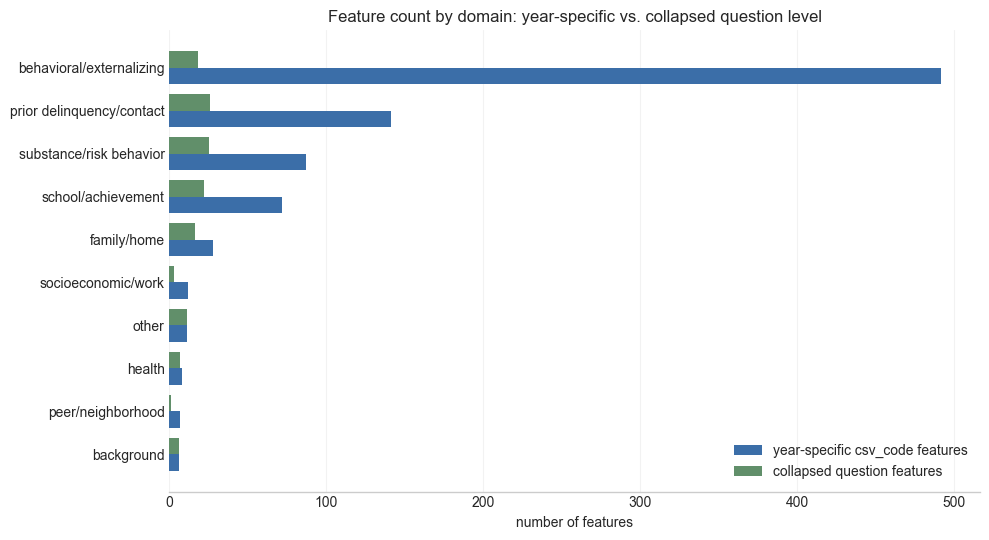

In [3]:
plot_df = collapsed_feature_summary.sort_values("year_specific_features", ascending=True)
y = np.arange(len(plot_df))
height = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(y - height / 2, plot_df["year_specific_features"], height=height, label="year-specific csv_code features", color="#3b6ea8")
ax.barh(y + height / 2, plot_df["collapsed_question_features"], height=height, label="collapsed question features", color="#618f6a")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature_group"])
ax.set_xlabel("number of features")
ax.set_title("Feature count by domain: year-specific vs. collapsed question level")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 3. Target-Defining Items and Missingness

The constructed target variables are built from direct delinquency/contact items observed between 2000 and 2020. The table below lists which raw item families enter the constructed targets, including reference codes and years.

Both target options use the same underlying direct item families:

- `later_any_delinquency_contact`: at least one positive item in at least one observed target year.
- `later_persistent_delinquency_contact`: positive items in at least two different observed target years.

The difference is how we frame the prediction task:

- **Option A, broad persistent:** use all respondents with observed target information and predict whether they have at least two positive direct delinquency/contact years.
- **Option B, reoffense after first event:** restrict to respondents with a first positive event and predict whether they have a later second positive event.

So Option B does not use new outcome items. It reuses the same item families, but makes the first event an index/history feature instead of part of the thing being predicted from baseline.


In [4]:
target_items = pd.read_csv(META / "later_broad_delinquency_contact_target_items.csv")
item_missing = pd.read_csv(META / "later_broad_delinquency_contact_item_missingness.csv")

# Add a readable conceptual category for each target-defining item family.
def classify_target_item(row):
    q = str(row["question"]).upper()
    var = str(row["variable"]).upper()
    if "PROBATION" in q or "YASR-67" in var:
        return "Justice contact: probation"
    if "CORRECTIONS" in q or "JAIL" in q or "REFORM" in q or "YASR-66" in var:
        return "Justice contact: corrections/jail/reform"
    if "PHYSICAL FIGHT" in q:
        return "Violence/aggression: physical fight"
    if "HURT SOMEONE" in q:
        return "Violence/aggression: hurt someone badly"
    if "DAMAGED" in q or "PROPERTY" in q:
        return "Property delinquency: damaged property"
    return "Other direct delinquency/contact item"

item_table = target_items.copy()
item_table["constructed_variable_type"] = "Direct item used for both any and persistent delinquency/contact targets"
item_table["target_item_category"] = item_table.apply(classify_target_item, axis=1)

# Family-level overview: easier to read than 69 separate item-year rows.
item_family_table = (
    item_table
    .groupby(["constructed_variable_type", "target_item_category", "variable", "question"], dropna=False)
    .agg(
        ref_codes=("ref_id", lambda x: ", ".join(sorted(set(map(str, x))))),
        years=("survey_year", lambda x: f"{int(min(x))}-{int(max(x))}"),
        n_item_years=("csv_code", "count"),
    )
    .reset_index()
    .sort_values(["target_item_category", "years", "variable"])
)

display(item_family_table)

# Optional detail table with missingness by exact item-year.
item_year_table = item_table.merge(
    item_missing[["csv_code", "n_nonmissing", "n_missing", "missing_rate", "positive_rate_among_nonmissing"]],
    on="csv_code",
    how="left",
)

display(
    item_year_table[[
        "constructed_variable_type", "target_item_category", "ref_id", "variable", "survey_year",
        "question", "n_nonmissing", "n_missing", "missing_rate", "positive_rate_among_nonmissing"
    ]].head(20)
)


,constructed_variable_type,target_item_category,variable,question,ref_codes,years,n_item_years
0,Direct item used for both any and persistent delinquency/contact targets,Justice contact: corrections/jail/reform,YASR-66,EVER/SINCE DATE OF LAST INTERVIEW R BEEN SENTENCED TO A CORRECTIONS,"Y11769.00, Y14175.00, Y16689.00, Y19422.00, Y22582.00, Y26098.00, Y29599.00, Y33263.00, Y36715.00, Y42763.00, Y45975.00",2000-2020,11
1,Direct item used for both any and persistent delinquency/contact targets,Justice contact: probation,YASR-67,EVER/SINCE DATE OF LAST INTERVIEW R BEEN ON PROBATION?,"Y11770.00, Y14176.00, Y16690.00, Y19423.00, Y22583.00, Y26099.00, Y29600.00, Y33264.00, Y36716.00, Y42764.00, Y45976.00",2000-2020,11
2,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,CSAS040E,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR DAMAGED SCHOOL PROPERTY ON,"C24664.00, C27661.00, C30458.00, C33666.00, C38703.00, C51185.00, C56960.00, C59679.00",2000-2014,8
4,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,YASR-60F,HOW MANY TIMES IN LAST YEAR R DAMAGED SCHOOL PROPERTY ON PURPOSE,"Y14162.00, Y16676.00, Y19409.00, Y22569.00, Y26085.00, Y29586.00",2002-2012,6
3,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,YASR-60B-J~000005,HOW MANY TIMES IN LAST YEAR R DAMAGED SCHOOL PROPERTY ON PURPOSE,"Y33257.04, Y36708.04, Y42756.04, Y45968.04",2014-2020,4
5,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,CSAS040B,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR HURT SOMEONE BAD ENOUGH TO,"C24661.00, C27658.00, C30455.00, C33663.00, C38700.00, C51182.00, C56957.00, C59676.00",2000-2014,8
7,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,YASR-60C,HOW MANY TIMES IN LAST YEAR R HURT SOMEONE BADLY ENOUGH TO NEED,"Y14159.00, Y16673.00, Y19406.00, Y22566.00, Y26082.00, Y29583.00",2002-2012,6
6,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,YASR-60B-J~000002,HOW MANY TIMES IN LAST YEAR R HURT SOMEONE BADLY ENOUGH TO NEED,"Y33257.01, Y36708.01, Y42756.01, Y45968.01",2014-2020,4
9,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: physical fight,YASR-61B,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,"Y11762.00, Y14168.00, Y16682.00, Y19415.00, Y22575.00, Y26091.00, Y29592.00",2000-2012,7
8,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: physical fight,YASR-61A-D~000002,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,"Y33258.01, Y36709.01, Y42757.01, Y45969.01",2014-2020,4


,constructed_variable_type,target_item_category,ref_id,variable,survey_year,question,n_nonmissing,n_missing,missing_rate,positive_rate_among_nonmissing
0,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,C24661.00,CSAS040B,2000,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR HURT SOMEONE BAD ENOUGH TO,735,4004,0.844904,0.194558
1,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,C24664.00,CSAS040E,2000,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR DAMAGED SCHOOL PROPERTY ON,738,4001,0.844271,0.070461
2,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: physical fight,Y11762.00,YASR-61B,2000,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,1455,3284,0.692973,0.124399
3,Direct item used for both any and persistent delinquency/contact targets,Justice contact: corrections/jail/reform,Y11769.00,YASR-66,2000,EVER/SINCE DATE OF LAST INTERVIEW R BEEN SENTENCED TO A CORRECTIONS,105,4634,0.977843,0.409524
4,Direct item used for both any and persistent delinquency/contact targets,Justice contact: probation,Y11770.00,YASR-67,2000,EVER/SINCE DATE OF LAST INTERVIEW R BEEN ON PROBATION?,1453,3286,0.693395,0.081211
5,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,C27658.00,CSAS040B,2002,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR HURT SOMEONE BAD ENOUGH TO,720,4019,0.848069,0.229167
6,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,C27661.00,CSAS040E,2002,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR DAMAGED SCHOOL PROPERTY ON,718,4021,0.848491,0.103064
7,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: hurt someone badly,Y14159.00,YASR-60C,2002,HOW MANY TIMES IN LAST YEAR R HURT SOMEONE BADLY ENOUGH TO NEED,752,3987,0.841317,1.000000
8,Direct item used for both any and persistent delinquency/contact targets,Property delinquency: damaged property,Y14162.00,YASR-60F,2002,HOW MANY TIMES IN LAST YEAR R DAMAGED SCHOOL PROPERTY ON PURPOSE,751,3988,0.841528,1.000000
9,Direct item used for both any and persistent delinquency/contact targets,Violence/aggression: physical fight,Y14168.00,YASR-61B,2002,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,1118,3621,0.764085,0.038462


## 4. Latest Target Construction: What Counts as 1 and 0?

The current main target remains `later_persistent_delinquency_contact`. We can also report an additional reoffense framing, `later_reoffend_after_first_delinquency_contact`, as an alternative analysis.

### 4.1 What behavior/contact counts toward the target?

A survey year is counted as a **positive delinquency/contact year** if at least one direct item in that year indicates any of the following:

1. **Physical fight at school or work**  
   Example item family: `YASR-61B` / `YASR-61A-D~000002`  
   Meaning: respondent reports getting into a physical fight at school or work in the last year.

2. **Hurt someone badly enough to need attention**  
   Example item family: `CSAS040B`, `YASR-60C`, `YASR-60B-J~000002`  
   Meaning: respondent reports hurting someone badly enough to need medical attention or similar care.

3. **Damaged property on purpose**  
   Example item family: `CSAS040E`, `YASR-60F`, `YASR-60B-J~000005`  
   Meaning: respondent reports intentionally damaging school/property.

4. **Probation**  
   Example item family: `YASR-67`  
   Meaning: respondent reports being on probation since the last interview or in the relevant recall window.

5. **Corrections/jail/reform sentence**  
   Example item family: `YASR-66`  
   Meaning: respondent reports being sentenced to corrections, jail, or reform since the last interview or in the relevant recall window.

These are **direct delinquency/contact indicators**. We did **not** define the target using indirect risk-only items such as seeing another student carry a weapon. Such items can be useful predictors if they occur before the cutoff, but they are not counted as the outcome.

### 4.2 Option A: broad persistent target

For each person, we scan all available target item years from 2000--2020.

```text
later_persistent_delinquency_contact = 1
if the person has direct delinquency/contact indicators in two or more different observed survey years.

later_persistent_delinquency_contact = 0
if the person has target information observed but has zero or only one positive target year.

later_persistent_delinquency_contact = missing
if the person has no observed target information in the relevant target-item set.
```

This is the first/current target because it asks for repeated delinquency/contact while keeping the full observed target cohort.

### 4.3 Option B: reoffense after a first event

For the additional reoffense option, the first positive direct delinquency/contact year becomes the **index event**.

```text
first_event_year = earliest observed target year with at least one positive direct delinquency/contact item
```

Among people with a first event:

```text
later_reoffend_after_first_delinquency_contact = 1
if the person has a second positive direct delinquency/contact year after the first event year.

later_reoffend_after_first_delinquency_contact = 0
if the person has a first positive direct delinquency/contact year but no later second positive year during observed follow-up.

later_reoffend_after_first_delinquency_contact = missing / out of cohort
if the person never has a first observed direct delinquency/contact event.
```

This is numerically equivalent to the persistent target **within the first-event cohort**, but the scientific question is different: conditional on a first event, who reoffends?

### 4.4 Person-specific cutoff year

The cutoff year prevents future information from leaking into the Book of Life.

For Option A, a **positive persistent case** is cut off before the **second positive target year**. A negative case is cut off before the person's **last observed target year**.

For Option B, the same second-event cutoff applies for positive reoffense cases, but the first event is interpreted as observed history/index information. Negative reoffense cases are also cut off before the last observed target year.

This is important because two people can have different valid prediction windows. Someone whose second event occurs in 2004 must not receive 2008 predictors, while someone observed until 2020 without persistence can validly use much later pre-cutoff information.


In [5]:
target_items = pd.read_csv(META / "later_broad_delinquency_contact_target_items.csv")
item_families = (
    target_items
    .groupby(["variable", "question"], dropna=False)
    .agg(
        first_year=("survey_year", "min"),
        last_year=("survey_year", "max"),
        n_items=("csv_code", "count"),
    )
    .reset_index()
    .sort_values(["first_year", "variable"])
)

display(item_families)


,variable,question,first_year,last_year,n_items
0,CSAS040B,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR HURT SOMEONE BAD ENOUGH TO,2000,2014,8
1,CSAS040E,CHILD SELF-ADMIN: HOW OFTEN IN LAST YEAR DAMAGED SCHOOL PROPERTY ON,2000,2014,8
7,YASR-61B,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,2000,2012,7
8,YASR-66,EVER/SINCE DATE OF LAST INTERVIEW R BEEN SENTENCED TO A CORRECTIONS,2000,2020,11
9,YASR-67,EVER/SINCE DATE OF LAST INTERVIEW R BEEN ON PROBATION?,2000,2020,11
4,YASR-60C,HOW MANY TIMES IN LAST YEAR R HURT SOMEONE BADLY ENOUGH TO NEED,2002,2012,6
5,YASR-60F,HOW MANY TIMES IN LAST YEAR R DAMAGED SCHOOL PROPERTY ON PURPOSE,2002,2012,6
2,YASR-60B-J~000002,HOW MANY TIMES IN LAST YEAR R HURT SOMEONE BADLY ENOUGH TO NEED,2014,2020,4
3,YASR-60B-J~000005,HOW MANY TIMES IN LAST YEAR R DAMAGED SCHOOL PROPERTY ON PURPOSE,2014,2020,4
6,YASR-61A-D~000002,IN LAST YEAR R EVER GOTTEN INTO A PHYSICAL FIGHT AT SCHOOL OR WORK,2014,2020,4


,target,total_n,eligible_n,missing_n,positive_n,negative_n,base_rate
0,later_any_delinquency_contact,4739,4122,617,3064,1058,0.743328
1,later_persistent_delinquency_contact,4739,4122,617,2109,2013,0.511645
2,later_reoffend_after_first_delinquency_contact,4739,3064,1675,2109,955,0.688316


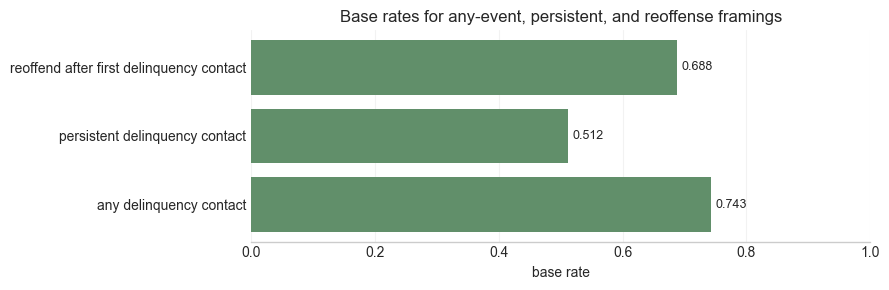

In [6]:
target_rates = pd.read_csv(META / "target_base_rates.csv")

# Reoffense framing: condition on having a first direct delinquency/contact event.
full_targets_path = FULL_BROAD / "child_crime_broad_persistent_targets.csv" if FULL_BROAD is not None else None
if full_targets_path is not None and full_targets_path.exists():
    full_targets = pd.read_csv(full_targets_path)
    reoffense_cohort = full_targets[full_targets["later_delinquency_contact_first_event_year"].notna()].copy()
    reoffense_summary = pd.DataFrame([{
        "target": "later_reoffend_after_first_delinquency_contact",
        "total_n": len(full_targets),
        "eligible_n": len(reoffense_cohort),
        "missing_n": len(full_targets) - len(reoffense_cohort),
        "positive_n": int(reoffense_cohort["later_delinquency_contact_second_event_year"].notna().sum()),
        "negative_n": int(reoffense_cohort["later_delinquency_contact_second_event_year"].isna().sum()),
        "base_rate": float(reoffense_cohort["later_delinquency_contact_second_event_year"].notna().mean()),
    }])
else:
    any_row = target_rates[target_rates["target"].eq("later_any_delinquency_contact")].iloc[0]
    persistent_row = target_rates[target_rates["target"].eq("later_persistent_delinquency_contact")].iloc[0]
    reoffense_summary = pd.DataFrame([{
        "target": "later_reoffend_after_first_delinquency_contact",
        "total_n": int(any_row["total_n"]),
        "eligible_n": int(any_row["positive_n"]),
        "missing_n": int(any_row["total_n"] - any_row["positive_n"]),
        "positive_n": int(persistent_row["positive_n"]),
        "negative_n": int(any_row["positive_n"] - persistent_row["positive_n"]),
        "base_rate": float(persistent_row["positive_n"] / any_row["positive_n"]),
    }])

target_rates_with_reoffense = pd.concat([target_rates, reoffense_summary], ignore_index=True)
display(target_rates_with_reoffense)

plot_df = target_rates_with_reoffense.copy()
plot_df["target_label"] = plot_df["target"].str.replace("later_", "", regex=False).str.replace("_", " ")
show_bar_table(
    plot_df,
    label_col="target_label",
    value_col="base_rate",
    title="Base rates for any-event, persistent, and reoffense framings",
    max_value=1,
    color="#618f6a",
    fmt="{:.3f}",
)


,year,n
0,2000.0,438
1,2002.0,812
2,2004.0,413
3,2006.0,391
4,2008.0,313


,year,n
0,2002.0,265
1,2004.0,443
2,2006.0,359
3,2008.0,336
4,2010.0,265


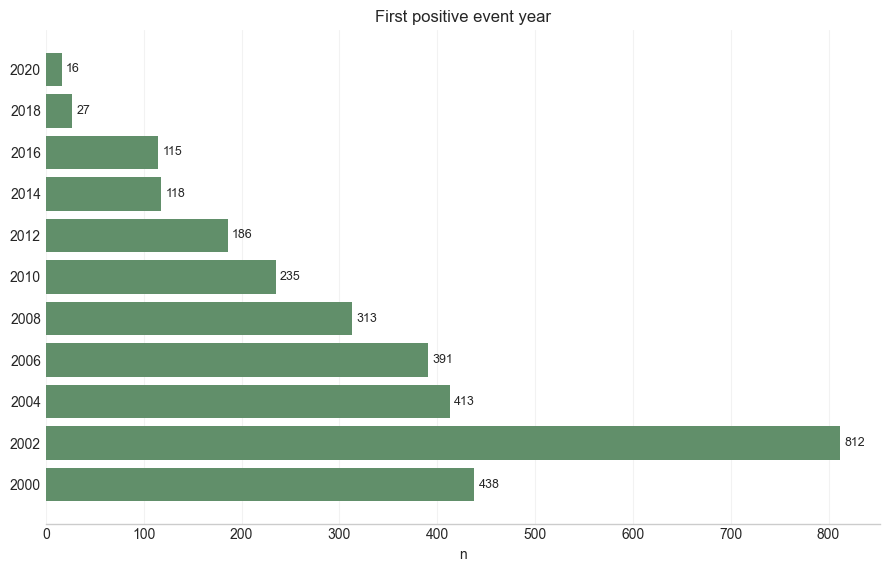

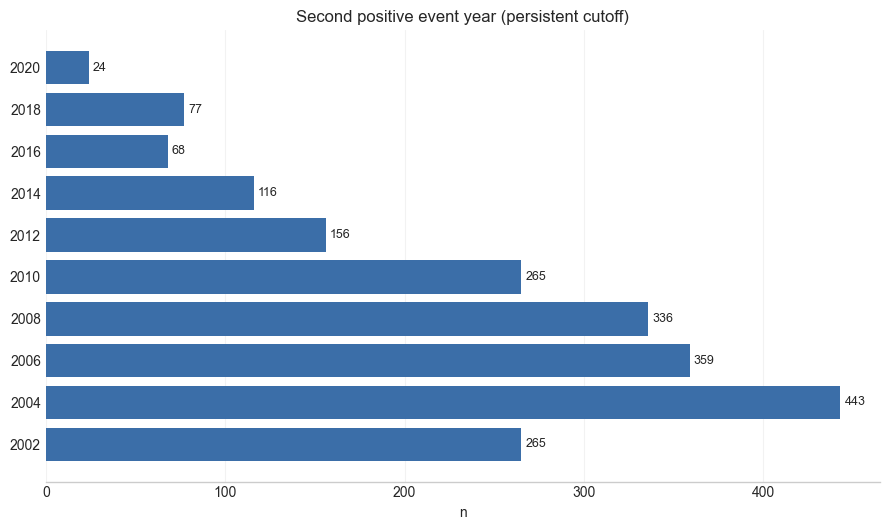

In [7]:
first_counts = pd.read_csv(META / "first_event_year_counts.csv")
second_counts = pd.read_csv(META / "second_event_year_counts.csv")

display(first_counts.head())
display(second_counts.head())

first_plot = first_counts.copy()
first_plot["year"] = first_plot["year"].astype(int).astype(str)
second_plot = second_counts.copy()
second_plot["year"] = second_plot["year"].astype(int).astype(str)

show_bar_table(first_plot, "year", "n", "First positive event year", color="#618f6a", fmt="{:.0f}")
show_bar_table(second_plot, "year", "n", "Second positive event year (persistent cutoff)", color="#3b6ea8", fmt="{:.0f}")


### 4.6 Important clarification: first event year and target option

The **first positive event year does count as evidence of delinquency/contact**, but it plays different roles in the two target framings.

Example cases:

| Observed target history | `later_any_delinquency_contact` | Option A: `later_persistent_delinquency_contact` | Option B: `later_reoffend_after_first_delinquency_contact` |
|---|---:|---:|---:|
| No positive target item in any observed year | 0 | 0 | missing / out of cohort |
| Positive item in 2006 only | 1 | 0 | 0 |
| Positive item in 2006 and 2010 | 1 | 1 | 1 |
| No target items observed at all | missing | missing | missing |

For Option A, the first event contributes to the count, but the person becomes positive only at the second positive event year.

For Option B, the first event is the index event that places the person into the analytic cohort. The target is whether there is a later second positive event year.


In [8]:
age_summary_path = META / "target_event_age_summary.csv"
if age_summary_path.exists():
    age_summary = pd.read_csv(age_summary_path)
else:
    # This fallback requires the full local data and is mainly for local project runs.
    selected_path = FULL_PROJECT / "output/share_with_team/nlsy79_child_youngadult_combined_bundle/nlsy79_child_youngadult_selected_crime_features.csv"
    targets_path = FULL_BROAD / "child_crime_broad_persistent_targets.csv"
    child_birth = pd.read_csv(selected_path, usecols=["C0000100", "C0005700"])
    target_data = pd.read_csv(targets_path)
    tmp = target_data.merge(child_birth, on="C0000100", how="left")
    tmp["age_first_event"] = tmp["later_delinquency_contact_first_event_year"] - tmp["C0005700"]
    tmp["age_second_event"] = tmp["later_delinquency_contact_second_event_year"] - tmp["C0005700"]
    tmp["age_last_observed"] = tmp["later_delinquency_contact_last_observed_year"] - tmp["C0005700"]
    rows = []
    for col, label in [
        ("age_first_event", "Age at first positive event"),
        ("age_second_event", "Age at second positive event"),
        ("age_last_observed", "Age at last observed target year"),
    ]:
        s = tmp[col].dropna()
        rows.append({
            "measure": label,
            "n": len(s),
            "mean": s.mean(),
            "sd": s.std(),
            "median": s.median(),
            "min": s.min(),
            "p25": s.quantile(0.25),
            "p75": s.quantile(0.75),
            "max": s.max(),
        })
    age_summary = pd.DataFrame(rows)

display(age_summary.round(2))


,measure,n,mean,sd,median,min,p25,p75,max
0,Age at first positive event,3064,16.40,4.20,16.0,10.0,15.0,17.0,45.0
1,Age at second positive event,2109,17.95,4.14,17.0,12.0,16.0,18.0,46.0
2,Age at last observed target year,4122,30.30,6.65,30.0,10.0,26.0,34.0,46.0


## 5. Base Rates and Descriptives by Fairness Group

For the 120-case LLM pilot, we evaluate fairness by sex and race/ethnicity. In a full paper, we should report these metrics on a held-out test set, not only the small balanced pilot.

The current fairness table includes base rate, predicted-positive rate, accuracy, AUC, TPR, FPR, FNR, PPV, and NPV.

,attribute,subgroup,n,base_rate,predicted_positive_rate,accuracy,auc,tpr,fpr,fnr,ppv
0,Sex,Female,58,0.448276,0.517241,0.896552,0.932091,0.961538,0.156250,0.038462,0.833333
1,Sex,Male,62,0.548387,0.500000,0.822581,0.867122,0.794118,0.142857,0.205882,0.870968
2,Race,Black,22,0.500000,0.500000,0.818182,0.913223,0.818182,0.181818,0.181818,0.818182
3,Race,Hispanic,13,0.307692,0.461538,0.846154,0.875000,1.000000,0.222222,0.000000,0.666667
4,Race,Non-Black/non-Hispanic,85,0.529412,0.517647,0.870588,0.891944,0.866667,0.125000,0.133333,0.886364


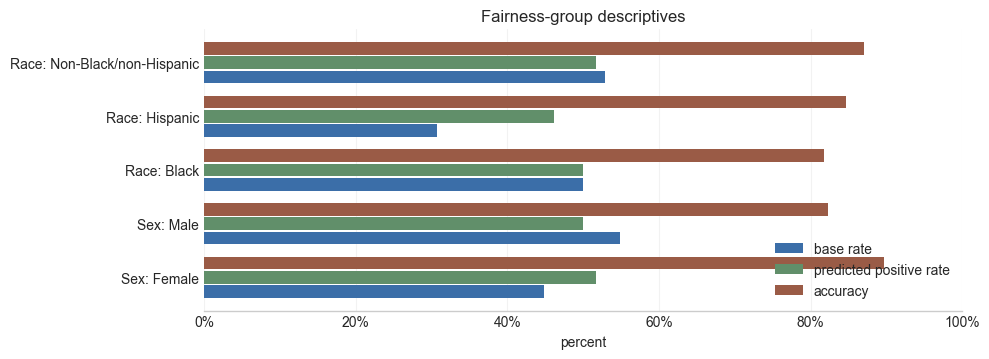

In [9]:
fairness = pd.read_csv(META / "child_crime_broad_persistent_fairness_metrics_120.csv")
cols = ["attribute", "subgroup", "n", "base_rate", "predicted_positive_rate", "accuracy", "auc", "tpr", "fpr", "fnr", "ppv"]
display(fairness[cols])

fairness_plot = fairness.copy()
fairness_plot["group"] = fairness_plot["attribute"] + ": " + fairness_plot["subgroup"]
show_metric_bar_table(
    fairness_plot,
    label_col="group",
    metric_cols=["base_rate", "predicted_positive_rate", "accuracy"],
    title="Fairness-group descriptives",
)


## 6. Book-of-Life Construction

The adapted script `create_child_bol_broad_persistent.py` creates the current broad-persistent BoL texts for Option A.

Main additions compared with the starter approach:

1. uses our broad persistent delinquency/contact target,
2. creates a person-specific cutoff year,
3. includes a richer domain-relevant feature index,
4. groups text by year and domain,
5. avoids post-outcome leakage.

The reoffense framing can be added as Option B using the same ingredients, but with the analytic cohort restricted to people with a first observed event and the prompt/target interpreted as later reoffense.

The cell below shows an anonymized example excerpt. If the full local BoL JSON exists, it can show one locally generated example as well.


In [10]:
example_text_path = META / "anonymized_example_bol.txt"
example_text = example_text_path.read_text()
print(example_text[:3500])

This Book of Life is a synthetic illustrative example. It is not a real NLSY79 respondent.
Only information observed before 2010 is included.
Stable background information: Sex of child: male; Race/ethnic cohort: not shown in this public example; Birth order of child: 2; Approximate birth cohort: late 1980s.
In 1994: family/home: household includes school-aged children; school/achievement: early school information is observed; behavioral/externalizing: behavior problem items show mostly low to moderate externalizing behavior.
In 1996: school/achievement: achievement and school context measures are available; behavioral/externalizing: a few items indicate arguing, impulsivity, or disobedience, but not consistently severe.
In 1998: substance/risk behavior: no clear substance-use indicator is shown in this synthetic example; peer/neighborhood: limited information is available.
In 2000: school/achievement: respondent is in the school/young-adult observation window; behavioral/externalizing

In [11]:
# Optional: show a real local example if the full project files are available.
# This cell does not call the OpenAI API.

if FULL_BROAD is not None:
    full_books = FULL_BROAD / "books_child_crime_broad_persistent_sample_120.json"
    print("Local full sample books exist:", full_books.exists())
    if full_books.exists():
        local_books = json.loads(full_books.read_text())
        first_id = next(iter(local_books))
        print("Local example child ID:", first_id)
        print(local_books[first_id]["text"][:3500])
else:
    print("Full local project not found in this package context.")

Local full sample books exist: False


## 7. Prediction Prompt: Zero-Shot and Few-Shot Style

The tutor's starter includes the idea of prompt-based prediction. For our project, we can distinguish:

- **zero-shot**: define the target and ask for a probability without examples;
- **few-shot/calibrated**: add short calibration examples describing what high-risk, low-risk, and mixed cases should look like.

The actual prediction script currently uses the Option A broad-persistent target. The prompt cell below keeps that first and also adds Option B prompt templates for the reoffense-after-first-event framing.


In [12]:
def make_persistent_zero_shot_prompt(book_text):
    return f"""Read the Book of Life below and predict whether this person will show persistent later delinquency/contact.

The target equals 1 if the person has direct delinquency/contact indicators in at least two different later survey years from 2000-2020. The indicators include physical fighting, hurting someone badly, damaging property, probation, or being sentenced to corrections/jail/reform. The Book of Life has already been cut off before the target point.

Return only valid JSON with exactly these keys:
{{"prediction": 0 or 1, "probability": number between 0 and 1, "reason": "one short sentence"}}

Book of Life:
{book_text}
"""


def make_persistent_few_shot_style_prompt(book_text):
    return f"""Read the Book of Life below and predict whether this person will show persistent later delinquency/contact.

The target equals 1 if the person has direct delinquency/contact indicators in at least two different later survey years from 2000-2020. The indicators include physical fighting, hurting someone badly, damaging property, probation, or being sentenced to corrections/jail/reform. The Book of Life has already been cut off before the target point.

Calibrate your probability. Examples:
- A person with repeated early externalizing behavior, prior substance use, prior fights/property damage, and weak school/family attachment should usually receive a higher probability, often above 0.50.
- A person with mostly stable school/family information, few behavioral risk indicators, and no prior delinquency/contact should usually receive a lower probability, often below 0.35.
- If the text is sparse or mixed, use an intermediate probability rather than defaulting to zero.

Return only valid JSON with exactly these keys:
{{"prediction": 0 or 1, "probability": number between 0 and 1, "reason": "one short sentence"}}

Make `prediction` consistent with `probability`: prediction must be 1 if probability >= 0.50 and 0 otherwise.
Use `probability` as your estimated probability that the target equals 1.

Book of Life:
{book_text}
"""


def make_reoffense_zero_shot_prompt(book_text):
    return f"""Read the Book of Life below and predict whether this person will reoffend after a first observed delinquency/contact event.

All people in this analytic cohort have already had at least one direct delinquency/contact event. The first event is part of the observed history, not the outcome. The target equals 1 if the person later has a second positive direct delinquency/contact survey year. Direct indicators include physical fighting, hurting someone badly, damaging property, probation, or being sentenced to corrections/jail/reform. The Book of Life has already been cut off before the target point.

Return only valid JSON with exactly these keys:
{{"prediction": 0 or 1, "probability": number between 0 and 1, "reason": "one short sentence"}}

Book of Life:
{book_text}
"""


def make_reoffense_few_shot_style_prompt(book_text):
    return f"""Read the Book of Life below and predict whether this person will reoffend after a first observed delinquency/contact event.

All people in this analytic cohort have already had at least one direct delinquency/contact event. The first event is part of the observed history, not the outcome. The target equals 1 if the person later has a second positive direct delinquency/contact survey year. Direct indicators include physical fighting, hurting someone badly, damaging property, probation, or being sentenced to corrections/jail/reform. The Book of Life has already been cut off before the target point.

Calibrate your probability. Examples:
- A person with repeated externalizing behavior, substance use, weak school/family attachment, and an early or severe first event should usually receive a higher reoffense probability, often above 0.50.
- A person whose first event looks isolated, with otherwise stable school/family information and few behavioral risk indicators, should usually receive a lower reoffense probability.
- If the text is sparse or mixed, use an intermediate probability rather than defaulting to zero.

Return only valid JSON with exactly these keys:
{{"prediction": 0 or 1, "probability": number between 0 and 1, "reason": "one short sentence"}}

Make `prediction` consistent with `probability`: prediction must be 1 if probability >= 0.50 and 0 otherwise.
Use `probability` as your estimated probability that the target equals 1.

Book of Life:
{book_text}
"""

# Backward-compatible names used elsewhere in the notebook.
make_zero_shot_prompt = make_persistent_zero_shot_prompt
make_few_shot_style_prompt = make_persistent_few_shot_style_prompt

short_book = example_text[:1800]
print("OPTION A: BROAD-PERSISTENT PROMPT EXCERPT")
print(make_persistent_few_shot_style_prompt(short_book)[:2400])
print()
print("="*80)
print()
print("OPTION B: REOFFENSE-AFTER-FIRST-EVENT PROMPT EXCERPT")
print(make_reoffense_few_shot_style_prompt(short_book)[:2400])


OPTION A: BROAD-PERSISTENT PROMPT EXCERPT
Read the Book of Life below and predict whether this person will show persistent later delinquency/contact.

The target equals 1 if the person has direct delinquency/contact indicators in at least two different later survey years from 2000-2020. The indicators include physical fighting, hurting someone badly, damaging property, probation, or being sentenced to corrections/jail/reform. The Book of Life has already been cut off before the target point.

Calibrate your probability. Examples:
- A person with repeated early externalizing behavior, prior substance use, prior fights/property damage, and weak school/family attachment should usually receive a higher probability, often above 0.50.
- A person with mostly stable school/family information, few behavioral risk indicators, and no prior delinquency/contact should usually receive a lower probability, often below 0.35.
- If the text is sparse or mixed, use an intermediate probability rather than

## 8. Exemplary Prediction Output

The prediction script writes one row per child with the model, target, binary prediction, probability, short reason, raw response, true label, cutoff year, and correctness indicator.

The saved example below is from the current Option A broad-persistent 120-case pilot. If we later run Option B, the output format can stay the same but the `target` field should become `later_reoffend_after_first_delinquency_contact` and the sample should be restricted to people with a first observed event.


In [13]:
example_output = json.loads((META / "example_prediction_output.json").read_text())
print(json.dumps(example_output, indent=2))

{
  "model": "gpt-5.4-nano",
  "target": "later_persistent_delinquency_contact",
  "prediction": 0,
  "probability": 0.34,
  "reason": "The synthetic book contains some mixed behavioral-risk indicators but no clear pre-cutoff pattern of repeated delinquency or justice contact.",
  "raw_response": "{\"prediction\":0,\"probability\":0.34,\"reason\":\"The synthetic book contains some mixed behavioral-risk indicators but no clear pre-cutoff pattern of repeated delinquency or justice contact.\"}",
  "y_true": null,
  "cutoff_year": 2010,
  "correct": null
}


In [ ]:
# Optional: run the OpenAI prediction script locally.
# This costs money and requires OPENAI_API_KEY in a local .env file.
# Do not run in a public notebook environment.
#
# import subprocess
# subprocess.run(["python3", "adapted_child_crime/predict_child_bol_broad_persistent_openai.py", "--overwrite"], check=True)

## 9. Threshold Evaluation

The LLM returns probabilities, but the decision threshold can be varied. In the latest Option A broad-persistent 120-case pilot, the best threshold was around 0.38. This should be treated as exploratory because the same sample was used to choose and evaluate the threshold.

If we add Option B, the threshold should be estimated separately on the reoffense cohort, because its base rate and task definition differ from the full broad-persistent cohort.


,threshold,accuracy,auc,sensitivity_tpr,specificity_tnr,fpr,fnr,predicted_positive_rate,tp,tn,fp,fn
0,0.38,0.858333,0.895417,0.866667,0.850000,0.150000,0.133333,0.508333,52,51,9,8
1,0.34,0.850000,0.895417,0.900000,0.800000,0.200000,0.100000,0.550000,54,48,12,6
2,0.35,0.850000,0.895417,0.866667,0.833333,0.166667,0.133333,0.516667,52,50,10,8
3,0.36,0.850000,0.895417,0.866667,0.833333,0.166667,0.133333,0.516667,52,50,10,8
4,0.35,0.841667,0.895417,0.883333,0.800000,0.200000,0.116667,0.541667,53,48,12,7
5,0.33,0.833333,0.895417,0.916667,0.750000,0.250000,0.083333,0.583333,55,45,15,5
6,0.30,0.825000,0.895417,0.933333,0.716667,0.283333,0.066667,0.608333,56,43,17,4
7,0.32,0.825000,0.895417,0.933333,0.716667,0.283333,0.066667,0.608333,56,43,17,4
8,0.29,0.816667,0.895417,0.933333,0.700000,0.300000,0.066667,0.616667,56,42,18,4
9,0.41,0.816667,0.895417,0.766667,0.866667,0.133333,0.233333,0.450000,46,52,8,14


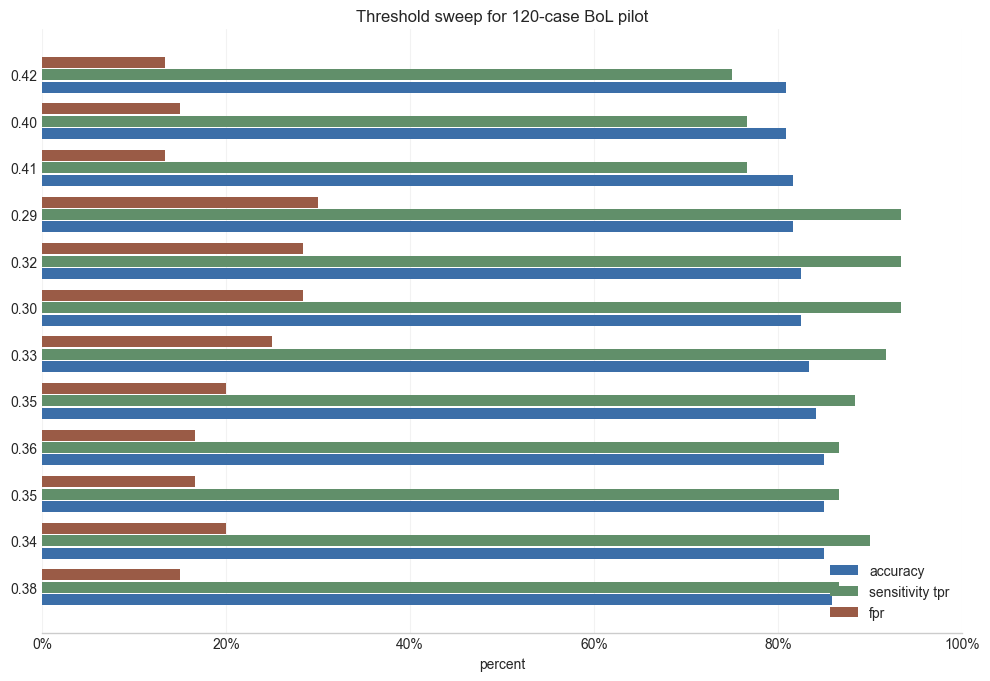

In [14]:
thresholds = pd.read_csv(META / "child_crime_broad_persistent_llm_threshold_eval_120.csv")
display(thresholds.head(10))

threshold_plot = thresholds.head(12).copy()
threshold_plot["threshold_label"] = threshold_plot["threshold"].map(lambda x: f"{x:.2f}")
show_metric_bar_table(
    threshold_plot,
    label_col="threshold_label",
    metric_cols=["accuracy", "sensitivity_tpr", "fpr"],
    title="Threshold sweep for 120-case BoL pilot",
)


## 10. Current Interpretation and Next Steps

The latest 120-case pilot is promising, but not final. The main target remains Option A, `later_persistent_delinquency_contact`, and Option B, `later_reoffend_after_first_delinquency_contact`, can be included as an additional robustness or alternative substantive framing.

The main scientific next step is a held-out comparison between:

1. tabular baseline models,
2. BoL direct prompting,
3. BoL embeddings plus a simple classifier,
4. versions with and without explicit protected attributes,
5. Option A broad-persistent versus Option B reoffense-after-first-event targets.

For the GitHub draft, the most important contribution is the workflow: target construction, person-specific cutoff logic, BoL text generation, and evaluation templates.
